In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv("https://raw.githubusercontent.com/amankharwal/Website-data/master/Billionaire.csv")
print(data.head())

Matplotlib is building the font cache; this may take a moment.


                       Name NetWorth        Country         Source  Rank  \
0                Jeff Bezos   $177 B  United States         Amazon     1   
1                 Elon Musk   $151 B  United States  Tesla, SpaceX     2   
2  Bernard Arnault & family   $150 B         France           LVMH     3   
3                Bill Gates   $124 B  United States      Microsoft     4   
4           Mark Zuckerberg    $97 B  United States       Facebook     5   

    Age          Industry  
0  57.0        Technology  
1  49.0        Automotive  
2  72.0  Fashion & Retail  
3  65.0        Technology  
4  36.0        Technology  


In [2]:
print(data.isnull().sum())

Name         0
NetWorth     0
Country      0
Source       0
Rank         0
Age         79
Industry     0
dtype: int64


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2755 entries, 0 to 2754
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      2755 non-null   object 
 1   NetWorth  2755 non-null   object 
 2   Country   2755 non-null   object 
 3   Source    2755 non-null   object 
 4   Rank      2755 non-null   int64  
 5   Age       2676 non-null   float64
 6   Industry  2755 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 150.8+ KB


In [5]:
data = data.dropna()

In [6]:
data

,Name,NetWorth,Country,Source,Rank,Age,Industry
0,Jeff Bezos,$177 B,United States,Amazon,1,57.0,Technology
1,Elon Musk,$151 B,United States,"Tesla, SpaceX",2,49.0,Automotive
2,Bernard Arnault & family,$150 B,France,LVMH,3,72.0,Fashion & Retail
3,Bill Gates,$124 B,United States,Microsoft,4,65.0,Technology
4,Mark Zuckerberg,$97 B,United States,Facebook,5,36.0,Technology
...,...,...,...,...,...,...,...
2750,Daniel Yong Zhang,$1 B,China,e-commerce,2674,49.0,Technology
2751,Zhang Yuqiang,$1 B,China,Fiberglass,2674,65.0,Manufacturing
2752,Zhao Meiguang,$1 B,China,gold mining,2674,58.0,Metals & Mining
2753,Zhong Naixiong,$1 B,China,conglomerate,2674,58.0,Diversified


In [7]:
print(data.isnull().sum())

Name        0
NetWorth    0
Country     0
Source      0
Rank        0
Age         0
Industry    0
dtype: int64


In [13]:
data = data.copy()  # Make an explicit copy to avoid the warning
data["NetWorth"] = (
    data["NetWorth"]
    .astype(str)
    .str.strip("$")
    .str.strip("B")
    .replace('nan', '0')
    .astype(float)
)


In [14]:
data

,Name,NetWorth,Country,Source,Rank,Age,Industry
0,Jeff Bezos,177.0,United States,Amazon,1,57.0,Technology
1,Elon Musk,151.0,United States,"Tesla, SpaceX",2,49.0,Automotive
2,Bernard Arnault & family,150.0,France,LVMH,3,72.0,Fashion & Retail
3,Bill Gates,124.0,United States,Microsoft,4,65.0,Technology
4,Mark Zuckerberg,97.0,United States,Facebook,5,36.0,Technology
...,...,...,...,...,...,...,...
2750,Daniel Yong Zhang,1.0,China,e-commerce,2674,49.0,Technology
2751,Zhang Yuqiang,1.0,China,Fiberglass,2674,65.0,Manufacturing
2752,Zhao Meiguang,1.0,China,gold mining,2674,58.0,Metals & Mining
2753,Zhong Naixiong,1.0,China,conglomerate,2674,58.0,Diversified


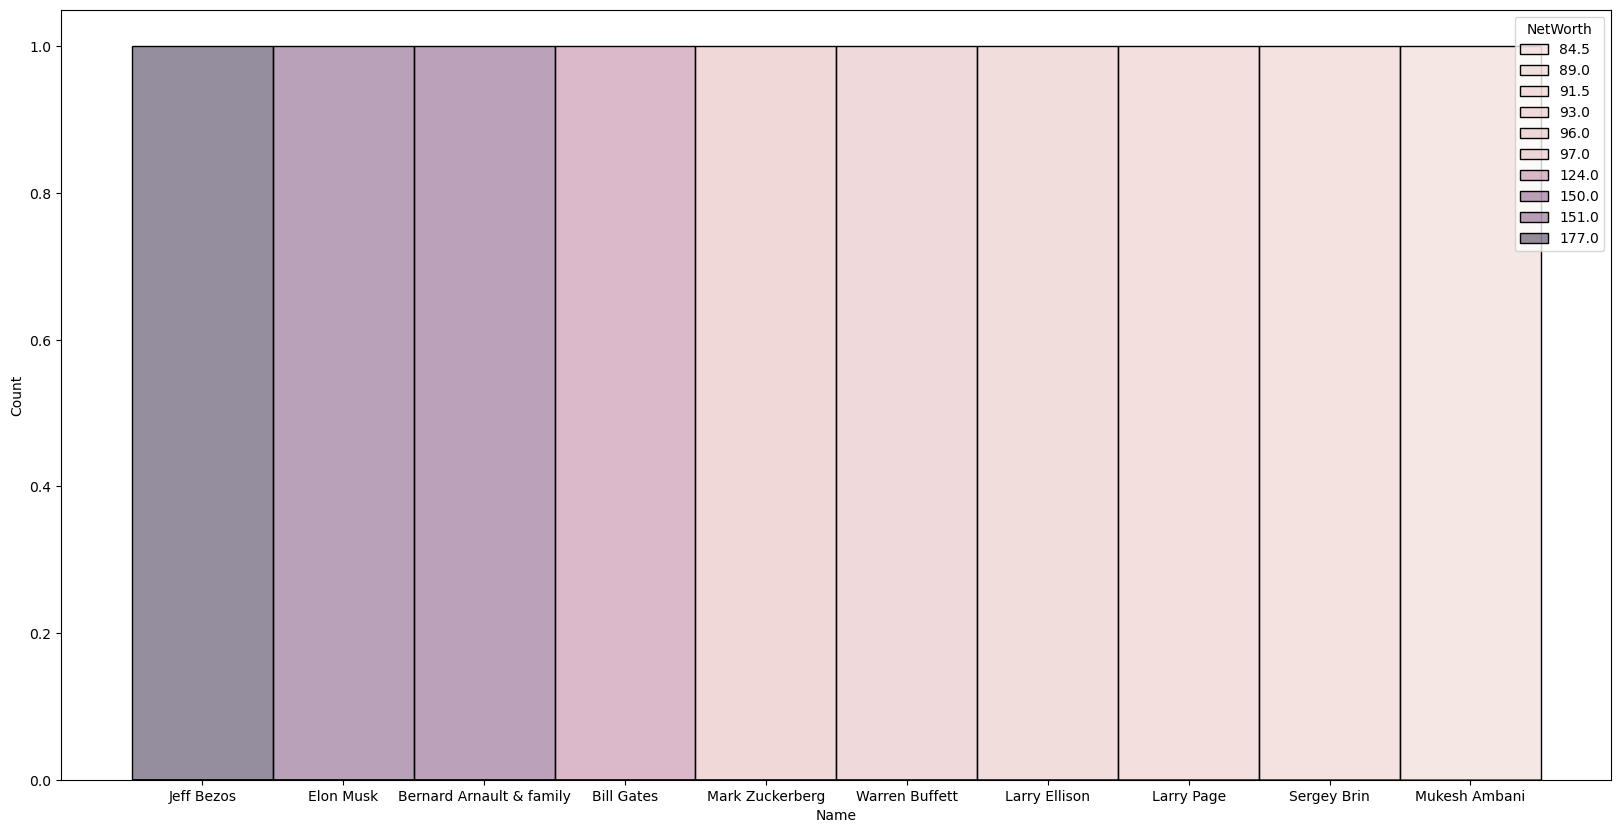

In [16]:
df = data.sort_values(by = ["NetWorth"], ascending=False).head(10)
plt.figure(figsize=(20, 10))
sns.histplot(x="Name", hue="NetWorth", data=df)
plt.show()


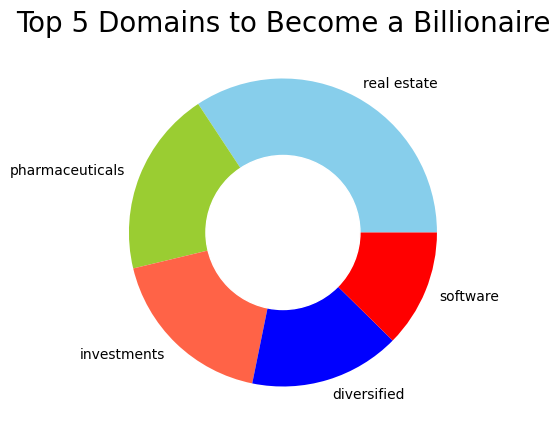

In [17]:
a = data["Source"].value_counts().head()
index = a.index
sources = a.values
custom_colors = ["skyblue", "yellowgreen", 'tomato', "blue", "red"]
plt.figure(figsize=(5, 5))
plt.pie(sources, labels=index, colors=custom_colors)
central_circle = plt.Circle((0, 0), 0.5, color='white')
fig = plt.gcf()
fig.gca().add_artist(central_circle)
plt.rc('font', size=12)
plt.title("Top 5 Domains to Become a Billionaire", fontsize=20)
plt.show()

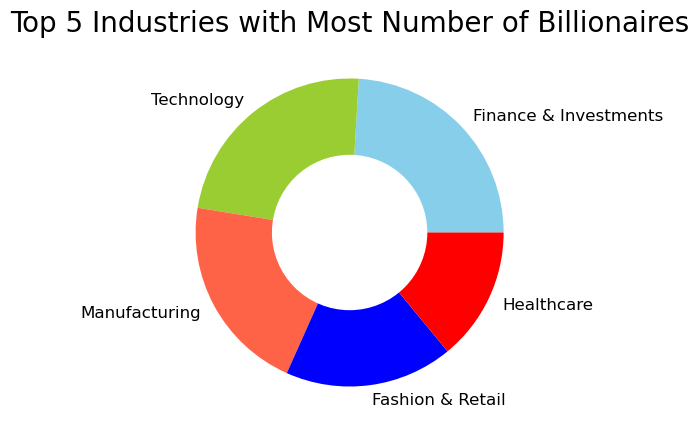

In [18]:
a = data["Industry"].value_counts().head()
index = a.index
industries = a.values
custom_colors = ["skyblue", "yellowgreen", 'tomato', "blue", "red"]
plt.figure(figsize=(5, 5))
plt.pie(industries, labels=index, colors=custom_colors)
central_circle = plt.Circle((0, 0), 0.5, color='white')
fig = plt.gcf()
fig.gca().add_artist(central_circle)
plt.rc('font', size=12)
plt.title("Top 5 Industries with Most Number of Billionaires", fontsize=20)
plt.show()